<a href="https://colab.research.google.com/github/nadjakencana/2025_Kecerdasan_Buatan_TI1b/blob/main/airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
df_airbnb = pd.read_csv('./airbnb.csv')
df_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Check Data Info

---

### Info Kolom dan Missing Value

In [3]:
# Tipe data, non-null, dan missing value
df_airbnb.info()

print("\nJumlah Missing Value per Kolom:\n")
print(df_airbnb.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

### pengaliasan agar lebih singkat

In [4]:
df = df_airbnb


### Statistik deskriptif

In [5]:
# Statistik numerik umum
df.describe()


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [6]:

# Tambahan: median
df.median(numeric_only=True)


,0
id,1.967728e+07
host_id,3.079382e+07
latitude,4.072307e+01
longitude,-7.395568e+01
price,1.060000e+02
minimum_nights,3.000000e+00
number_of_reviews,5.000000e+00
reviews_per_month,7.200000e-01
calculated_host_listings_count,1.000000e+00
availability_365,4.500000e+01


### Harga: Min vs Maks & Rasio

In [7]:
min_price = df_airbnb['price'].min()
max_price = df_airbnb['price'].max()

print(f"Harga minimal: {min_price}")
print(f"Harga maksimal: {max_price}")

if min_price > 0:
    ratio = max_price / min_price
    print(f"Perbandingan harga max:min = {ratio:.2f}")
else:
    print("Tidak bisa membandingkan karena harga minimal adalah 0 (data kemungkinan outlier).")


Harga minimal: 0
Harga maksimal: 10000
Tidak bisa membandingkan karena harga minimal adalah 0 (data kemungkinan outlier).


### Visualisasi Data

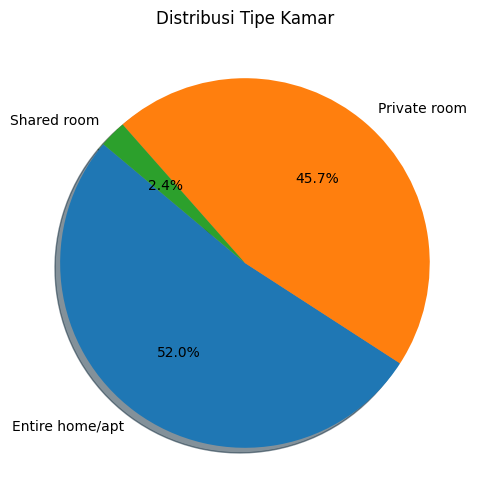

In [8]:
room_counts = df['room_type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(room_counts, labels=room_counts.index, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Distribusi Tipe Kamar')
plt.show()


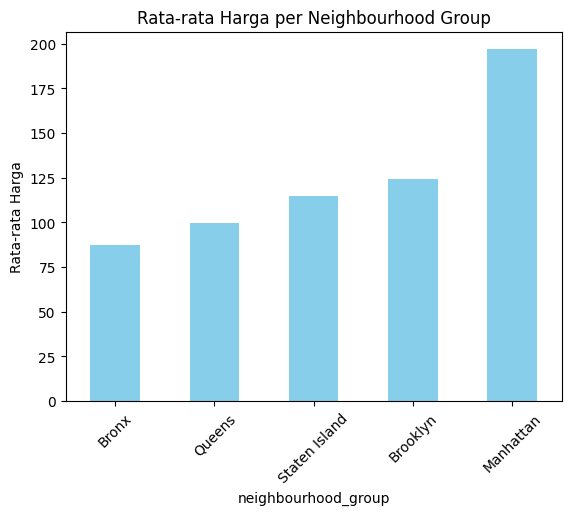

In [9]:
group_price = df.groupby('neighbourhood_group')['price'].mean().sort_values()
group_price.plot(kind='bar', color='skyblue')
plt.ylabel("Rata-rata Harga")
plt.title("Rata-rata Harga per Neighbourhood Group")
plt.xticks(rotation=45)
plt.show()


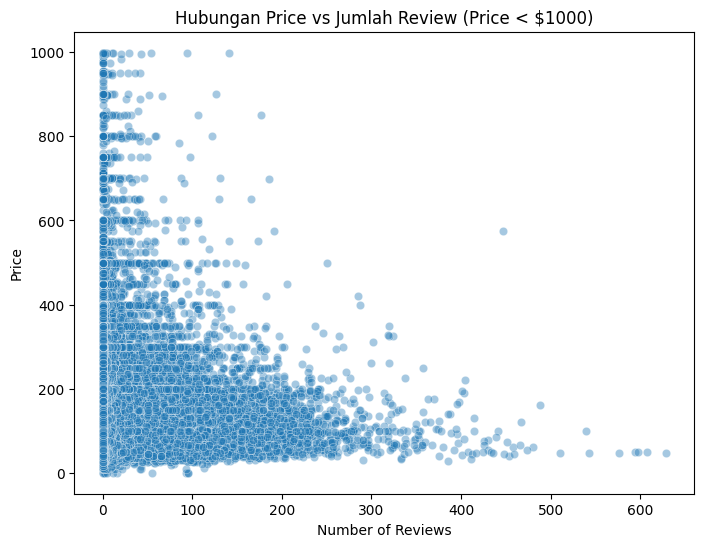

In [10]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df[df['price'] < 1000], x='number_of_reviews', y='price', alpha=0.4)
plt.title('Hubungan Price vs Jumlah Review (Price < $1000)')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.show()


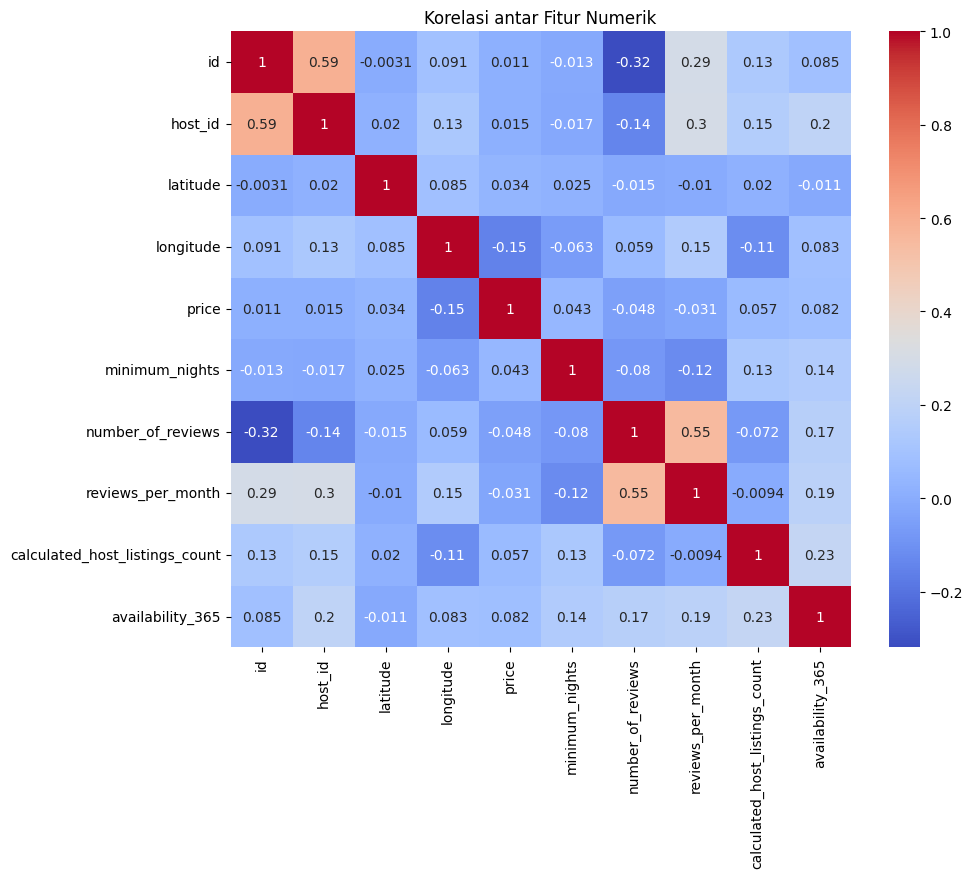

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df_airbnb.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Korelasi antar Fitur Numerik')
plt.show()


### Insight Menarik

####
- Tipe kamar paling umum adalah Entire home/apt (sekitar X% dari total listing).
- Neighbourhood group dengan harga rata-rata tertinggi adalah Manhattan.
- Harga listing sangat bervariasi, dengan perbandingan harga maksimal dan minimal mencapai 1000x lipat lebih.
- Banyak listing murah (di bawah $1000) tetap memiliki review tinggi, artinya harga bukan satu-satunya indikator kualitas.


### Kesimpulan

In [12]:
print("Berdasarkan analisis data AirBnB New York 2019, dapat disimpulkan bahwa lokasi dan tipe properti sangat mempengaruhi harga listing. Visualisasi juga menunjukkan adanya outlier harga yang sangat tinggi. Analisis ini dapat membantu host baru dalam menentukan harga yang kompetitif berdasarkan wilayah dan jenis akomodasi yang tersedia.")


Berdasarkan analisis data AirBnB New York 2019, dapat disimpulkan bahwa lokasi dan tipe properti sangat mempengaruhi harga listing. Visualisasi juga menunjukkan adanya outlier harga yang sangat tinggi. Analisis ini dapat membantu host baru dalam menentukan harga yang kompetitif berdasarkan wilayah dan jenis akomodasi yang tersedia.
